In [1]:
#| default_exp fid

In [2]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [3]:
!pip install -Uqq git+https://github.com/1iyiwei/course22p2

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 5.9 MB/s eta 0:00:00


# FID

In [4]:
#|export
import pickle,gzip,math,os,time,shutil,torch,random
import fastcore.all as fc,matplotlib as mpl,numpy as np,matplotlib.pyplot as plt
from collections.abc import Mapping
from pathlib import Path
from operator import attrgetter,itemgetter
from functools import partial
from copy import copy
from contextlib import contextmanager
from scipy import linalg

from fastcore.foundation import L
import torchvision.transforms.functional as TF,torch.nn.functional as F
from torch import tensor,nn,optim
from torch.utils.data import DataLoader,default_collate
from torch.nn import init
from torch.optim import lr_scheduler
from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset,load_dataset_builder

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *
from miniai.resnet import *
from miniai.augment import *
from miniai.accel import *

In [5]:
from fastcore.test import test_close
from torch import distributions

torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)
mpl.rcParams['image.cmap'] = 'gray_r'

import logging
logging.disable(logging.WARNING)

set_seed(42)
if fc.defaults.cpus>8: fc.defaults.cpus=8

## Classifier

In [6]:
xl,yl = 'image','label'
name = "zalando-datasets/fashion_mnist"
bs = 512

@inplace
def transformi(b): b[xl] = [F.pad(TF.to_tensor(o), (2,2,2,2))*2-1 for o in b[xl]]

dsd = load_dataset(name)
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=fc.defaults.cpus)

README.md: 0.00B [00:00, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [7]:
b = xb,yb = next(iter(dls.train))

In [8]:
from IPython.core.magic import register_cell_magic

@register_cell_magic
def skip(line, cell):
    return

In [9]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [10]:
# from 14_augment.ipynb
def get_model(act=nn.ReLU, nfs=(16,32,64,128,256,512), norm=nn.BatchNorm2d):
    layers = [ResBlock(1, 16, ks=5, stride=1, act=act, norm=norm)]
    layers += [ResBlock(nfs[i], nfs[i+1], act=act, norm=norm, stride=2) for i in range(len(nfs)-1)]
    layers += [nn.Flatten(), nn.Linear(nfs[-1], 10, bias=False), nn.BatchNorm1d(10)]
    return nn.Sequential(*layers)

act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)

from torchvision import transforms
def tfm_batch(b, tfm_x=fc.noop, tfm_y = fc.noop): return tfm_x(b[0]),tfm_y(b[1])

tfms = nn.Sequential(transforms.RandomCrop(28, padding=4),
                     transforms.RandomHorizontalFlip())

augcb = BatchTransformCB(partial(tfm_batch, tfm_x=tfms), on_val=False)

metrics = MetricsCB(accuracy=MulticlassAccuracy())
astats = ActivationStats(fc.risinstance(GeneralRelu))
iw = partial(init_weights, leaky=0.1)

data_aug2_output = Path('models/data_aug2.pkl')
try:
    model = torch.load(data_aug2_output, weights_only=False, map_location=device)
except Exception as e:
    print(e)
    try:
        kaggle_location='/kaggle/input/models/liyiwei/data-aug2-pkl/pytorch/default/1/data_aug2.pkl'
        model = torch.load(kaggle_location, weights_only=False, map_location=device)
    except Exception as e:
        print(e)
        cbs = [DeviceCB(), metrics, ProgressCB(plot=True), astats]
        set_seed(42)
        epochs = 20
        lr = 1e-2
        tmax = epochs * len(dls.train)
        sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
        xtra = [BatchSchedCB(sched), augcb]
        model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
        learn = TrainLearner(model, dls, F.cross_entropy, lr=lr, cbs=cbs+xtra, opt_func=optim.AdamW)
        learn.fit(epochs)
        model = learn.model
        data_aug2_output.parent.mkdir(parents=True, exist_ok=True)
        torch.save(model, data_aug2_output)

cbs = [DeviceCB(), MixedPrecision()]
learn = Learner(model, dls, F.cross_entropy, cbs=cbs)
learn.summary()

[Errno 2] No such file or directory: 'models/data_aug2.pkl'


/usr/local/lib/python3.12/dist-packages/miniai/accel.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  def before_fit(self, learn): self.scaler = torch.cuda.amp.GradScaler()


Tot params: 4907588; MFLOPS: 25.3


|Module|Input|Output|Num params|MFLOPS|
|--|--|--|--|--|
|ResBlock|(512, 1, 32, 32)|(512, 16, 32, 32)|6928|7.0|
|ResBlock|(512, 16, 32, 32)|(512, 32, 16, 16)|14560|3.7|
|ResBlock|(512, 32, 16, 16)|(512, 64, 8, 8)|57792|3.7|
|ResBlock|(512, 64, 8, 8)|(512, 128, 4, 4)|230272|3.7|
|ResBlock|(512, 128, 4, 4)|(512, 256, 2, 2)|919296|3.7|
|ResBlock|(512, 256, 2, 2)|(512, 512, 1, 1)|3673600|3.7|
|Flatten|(512, 512, 1, 1)|(512, 512)|0|0.0|
|Linear|(512, 512)|(512, 10)|5120|0.0|
|BatchNorm1d|(512, 10)|(512, 10)|20|0.0|


In [11]:
def append_outp(hook, mod, inp, outp):
    if not hasattr(hook,'outp'): hook.outp = []
    hook.outp.append(to_cpu(outp))

In [12]:
hcb = HooksCallback(append_outp, mods=[learn.model[6]], on_valid=True)

In [13]:
learn.fit(1, train=False, cbs=[hcb])

In [14]:
feats = hcb.hooks[0].outp[0].float()[:64]
feats.shape

torch.Size([64, 512])

In [15]:
del(learn.model[8])
del(learn.model[7])

In [16]:
feats,y = learn.capture_preds()
feats = feats.float()
feats.shape,y

(torch.Size([10000, 512]), tensor([9, 2, 1,  ..., 8, 1, 5]))

## Calc FID

In [17]:
betamin,betamax,n_steps = 0.0001,0.02,1000
beta = torch.linspace(betamin, betamax, n_steps)
alpha = 1.-beta
alphabar = alpha.cumprod(dim=0)
sigma = beta.sqrt()

In [18]:
def noisify(x0, ᾱ):
    device = x0.device
    n = len(x0)
    t = torch.randint(0, n_steps, (n,), dtype=torch.long)
    ε = torch.randn(x0.shape, device=device)
    ᾱ_t = ᾱ[t].reshape(-1, 1, 1, 1).to(device)
    xt = ᾱ_t.sqrt()*x0 + (1-ᾱ_t).sqrt()*ε
    return (xt, t.to(device)), ε

def collate_ddpm(b): return noisify(default_collate(b)[xl], alphabar)
def dl_ddpm(ds): return DataLoader(ds, batch_size=bs, collate_fn=collate_ddpm, num_workers=4)

In [19]:
dls2 = DataLoaders(dl_ddpm(tds['train']), dl_ddpm(tds['test']))

In [20]:
from diffusers import UNet2DModel

class UNet(UNet2DModel):
    def forward(self, x): return super().forward(*x).sample

In [21]:
try:
    smodel = torch.load(Path('models/fashion_ddpm_mp.pkl'), weights_only=False).cuda()
except:
    try:
        smodel = torch.load(Path('models/fashion_ddpm_mp.pkl'), weights_only=False, map_location=device)
    except:
        smodel = torch.load("/kaggle/input/models/liyiwei/fashion-ddpm-mp/pytorch/default/1/fashion_ddpm_mp.pkl", weights_only=False, map_location=device)

if device=='cuda':
    smodel = smodel.cuda()

In [22]:
@torch.no_grad()
def sample(model, sz, alpha, alphabar, sigma, n_steps):
    device = next(model.parameters()).device
    x_t = torch.randn(sz, device=device)
    preds = []
    for t in reversed(range(n_steps)):
        t_batch = torch.full((x_t.shape[0],), t, device=device, dtype=torch.long)
        z = (torch.randn(x_t.shape) if t > 0 else torch.zeros(x_t.shape)).to(device)
        ᾱ_t1 = alphabar[t-1]  if t > 0 else torch.tensor(1)
        b̄_t = 1 - alphabar[t]
        b̄_t1 = 1 - ᾱ_t1
        x_0_hat = ((x_t - b̄_t.sqrt() * model((x_t, t_batch)))/alphabar[t].sqrt())
        x_t = x_0_hat * ᾱ_t1.sqrt()*(1-alpha[t])/b̄_t + x_t * alpha[t].sqrt()*b̄_t1/b̄_t + sigma[t]*z
        preds.append(x_0_hat.cpu())
    return preds

In [23]:
%%time
samples = sample(smodel, (256, 1, 32, 32), alpha, alphabar, sigma, n_steps)

CPU times: user 1min 38s, sys: 566 ms, total: 1min 38s
Wall time: 1min 38s


In [24]:
len(samples), samples[0].shape

(1000, torch.Size([256, 1, 32, 32]))

In [25]:
s = samples[-1]*2-1

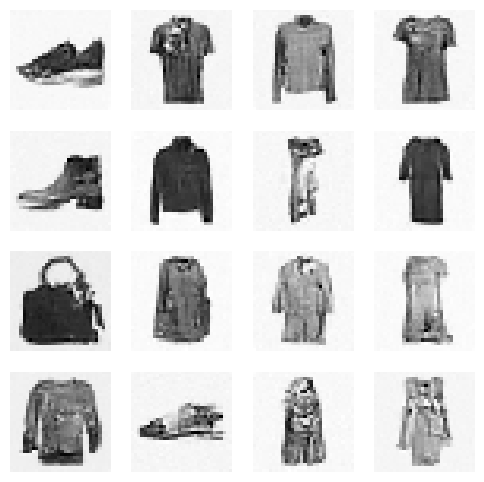

In [26]:
show_images(s[:16], imsize=1.5)

In [27]:
clearn = TrainLearner(model, DataLoaders([],[(s,yb)]), loss_func=fc.noop, cbs=[DeviceCB()], opt_func=None)
feats2,y2 = clearn.capture_preds()
print(feats2.shape)
feats2 = feats2.float().squeeze()
feats2.shape

torch.Size([256, 512])


torch.Size([256, 512])

In [28]:
means = feats2.mean(0)
means.shape

torch.Size([512])

In [29]:
covs = feats2.T.cov()
covs.shape

torch.Size([512, 512])

In [30]:
#|export
def _sqrtm_newton_schulz(mat, num_iters=100):
    mat_nrm = mat.norm()
    mat = mat.double()
    Y = mat/mat_nrm
    n = len(mat)
    I = torch.eye(n, n).to(mat)
    Z = torch.eye(n, n).to(mat)

    for i in range(num_iters):
        T = (3*I - Z@Y)/2
        Y,Z = Y@T,T@Z
        res = Y*mat_nrm.sqrt()
        if ((mat-(res@res)).norm()/mat_nrm).abs()<=1e-6: break
    return res

In [31]:
#|export
def _calc_stats(feats):
    feats = feats.squeeze()
    return feats.mean(0),feats.T.cov()

def _calc_fid(m1,c1,m2,c2):
#     csr = _sqrtm_newton_schulz(c1@c2)
    csr = tensor(linalg.sqrtm(c1@c2).real)
    return (((m1-m2)**2).sum() + c1.trace() + c2.trace() - 2*csr.trace()).item()

In [32]:
s1,s2 = _calc_stats(feats),_calc_stats(feats2)

In [33]:
_calc_fid(*s1, *s2)

238.18212890625

In [34]:
#|export
def _squared_mmd(x, y):
    def k(a,b): return (a@b.transpose(-2,-1)/a.shape[-1]+1)**3
    m,n = x.shape[-2],y.shape[-2]
    kxx,kyy,kxy = k(x,x), k(y,y), k(x,y)
    kxx_sum = kxx.sum([-1,-2])-kxx.diagonal(0,-1,-2).sum(-1)
    kyy_sum = kyy.sum([-1,-2])-kyy.diagonal(0,-1,-2).sum(-1)
    kxy_sum = kxy.sum([-1,-2])
    return kxx_sum/m/(m-1) + kyy_sum/n/(n-1) - kxy_sum*2/m/n

In [35]:
#|export
def _calc_kid(x, y, maxs=50):
    xs,ys = x.shape[0],y.shape[0]
    n = max(math.ceil(min(xs/maxs, ys/maxs)), 4)
    mmd = 0.
    for i in range(n):
        cur_x = x[round(i*xs/n) : round((i+1)*xs/n)]
        cur_y = y[round(i*ys/n) : round((i+1)*ys/n)]
        mmd += _squared_mmd(cur_x, cur_y)
    return (mmd/n).item()

In [36]:
_calc_kid(feats, feats2)

6.2569403648376465

## FID class

In [37]:
#|export
class ImageEval:
    def __init__(self, model, dls, cbs=None):
        self.learn = TrainLearner(model, dls, loss_func=fc.noop, cbs=cbs, opt_func=None)
        self.feats = self.learn.capture_preds()[0].float().cpu().squeeze()
        self.stats = _calc_stats(self.feats)

    def get_feats(self, samp):
        self.learn.dls = DataLoaders([],[(samp, tensor([0]))])
        return self.learn.capture_preds()[0].float().cpu().squeeze()

    def fid(self, samp): return _calc_fid(*self.stats, *_calc_stats(self.get_feats(samp)))
    def kid(self, samp): return _calc_kid(self.feats, self.get_feats(samp))

In [38]:
ie = ImageEval(model, learn.dls, cbs=[DeviceCB()])

In [39]:
%%time
ie.fid(s)

CPU times: user 1.26 s, sys: 5.71 ms, total: 1.27 s
Wall time: 335 ms


238.17626953125

In [40]:
%%time
ie.kid(s)

CPU times: user 567 ms, sys: 21.7 ms, total: 588 ms
Wall time: 180 ms


6.250617980957031

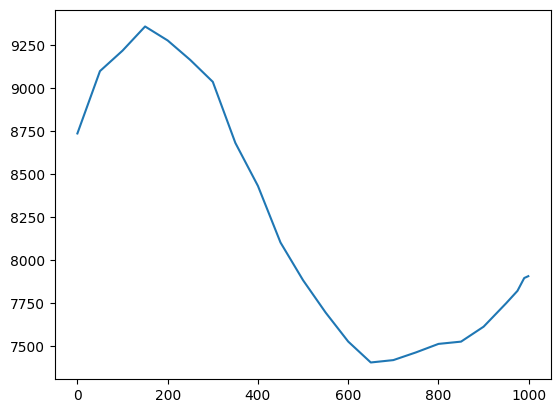

In [41]:
xs = L.range(0,1000,50)+[975,990,999]
plt.plot(xs, [ie.fid(samples[i].clamp(-0.5,0.5)*2) for i in xs]);

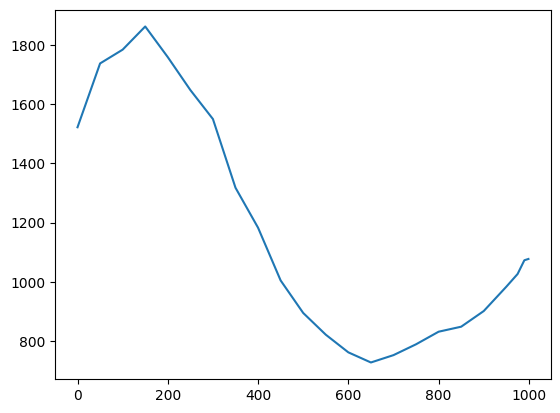

In [42]:
xs = L.range(0,1000,50)+[975,990,999]
plt.plot(xs, [ie.kid(samples[i].clamp(-0.5,0.5)*2) for i in xs]);

In [43]:
ie.fid(xb)

23.388671875

In [44]:
ie.kid(xb)

-0.2794501483440399

## Inception

In [45]:
!pip install pytorch-fid

In [46]:
from pytorch_fid.inception import InceptionV3

In [47]:
a = tensor([1,2,3])
a.repeat((3,1))

tensor([[1, 2, 3],
        [1, 2, 3],
        [1, 2, 3]])

In [48]:
class IncepWrap(nn.Module):
    def __init__(self):
        super().__init__()
        self.m = InceptionV3(resize_input=True)
    def forward(self, x): return self.m(x.repeat(1,3,1,1))[0]

In [49]:
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=fc.defaults.cpus)

In [51]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [52]:
ie = ImageEval(IncepWrap(), dls, cbs=[DeviceCB()])

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:00<00:00, 152MB/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 5.28 GiB. GPU 0 has a total capacity of 14.56 GiB of which 5.26 GiB is free. Including non-PyTorch memory, this process has 9.30 GiB memory in use. Of the allocated memory 9.09 GiB is allocated by PyTorch, and 64.01 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
%%time
ie.fid(s)

In [ ]:
ie.fid(xb)

In [ ]:
%%time
ie.kid(s)

In [ ]:
ie.kid(xb)

## Export -

In [ ]:
#import nbdev; nbdev.nbdev_export()